In [1]:
import os, sys
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors, cm
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from scipy.stats import bootstrap
from matplotlib.patches import Patch
from shapely import wkt

In [39]:
module_path = "../src"
sys.path.append(os.path.abspath(module_path))
from results_analysis_tc import *
from percolation_analysis_tc import prepare_loads_map

In [3]:
# INPUT PARAMETERS
base_dir = f"../outputs/20250725_hazard_iter_1000"

output_dir = "../figures/20250725_hazard_iter_1000"
os.makedirs(output_dir, exist_ok=True)

In [4]:
lines_gdf = gpd.read_file('../outputs/table_lines_200m_update_remove_disconnected.gpkg')
nodes_gdf = gpd.read_file('../outputs/table_nodes_200m_update_remove_disconnected.gpkg')
loads_gdf = gpd.read_file('../outputs/landuse_sites_gdf_add_bus.gpkg')
gens_gdf = gpd.read_file('../outputs/plant_update.gpkg')
basemap = gpd.read_file("../data/base_map/vnm_admbnda_adm1_gov_20201027.shp")

overload_lines_df = pd.read_csv(f"{base_dir}/overloaded_lines_records.csv")
failed_lines_df = pd.read_csv(f"{base_dir}/failed_lines_records.csv")
failed_nodes_df = pd.read_csv(f"{base_dir}/failed_buses_records.csv")
# load_ratio_df = pd.read_csv(f"{base_dir}/load_served_ratio.csv")
load_status_df = pd.read_csv(f"{base_dir}/load_status_records.csv")
results_df = pd.read_csv(f"{base_dir}/percolation_overall_results.csv")


In [6]:
nodes_gdf, lines_gdf, loads_gdf = assign_adm1_codes_with_ref_and_pcode(nodes_gdf, lines_gdf, loads_gdf, basemap)

In [7]:
# 读取 Excel 为 DataFrame
lines_df = pd.read_excel(f"{base_dir}/lines_gdf_sim_update.xlsx")
nodes_df = pd.read_excel(f"{base_dir}/nodes_gdf_sim_update.xlsx")

# 将 WKT 字符串转换为 Shapely geometry
lines_df["geometry"] = lines_df["geometry"].apply(wkt.loads)
nodes_df["geometry"] = nodes_df["geometry"].apply(wkt.loads)

# 转为 GeoDataFrame
lines_gdf_sim_update = gpd.GeoDataFrame(lines_df, geometry="geometry", crs="EPSG:4326")
nodes_gdf_sim_update = gpd.GeoDataFrame(nodes_df, geometry="geometry", crs="EPSG:4326")

In [9]:
# def plot_failure_impact_maps(lines_gdf_sim_update, nodes_gdf_sim_update, basemap, fig_path):
#     """
#     For each impact_* column, generate a 2-panel map showing failure status of lines and buses.
#     """
#     os.makedirs(fig_path, exist_ok=True)

#     # 提取所有 impact_* 列
#     impact_cols = [col for col in lines_gdf_sim_update.columns if col.startswith("impact_")]

#     # 区域底图划分
#     pcode_list = ['VN106', 'VN111', 'VN101', 'VN107', 'VN103', 'VN109', 'VN113', 'VN117', 'VN115', 'VN104']
#     target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
#     other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

#     # 状态颜色映射
#     # Colorblind friendly color schemes: https://scottplot.net/cookbook/4.1/colors/#category-20
#     # status_colors = {
#     #     'Not Failed': '#00B25D',
#     #     'Direct Failed': '#B51D14',
#     #     'Indirect Failed': '#4053D3'
#     # }
#     status_colors = {
#         'Not Failed': '#98DF8A',
#         'Direct Failed': '#D62728',
#         'Indirect Failed': '#1F77B4'
#     }

#     for impact_column in impact_cols:
#         fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#         # ========== 左图：线路 ========== #
#         ax = axes[0]
#         for status, color in status_colors.items():
#             subset = lines_gdf_sim_update[lines_gdf_sim_update[impact_column] == status]
#             if not subset.empty:
#                 subset.plot(ax=ax, color=color, linewidth=1.5, label=status, zorder=3)

#         target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5, alpha=0.5, zorder=1)
#         other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.3, zorder=0)

#         ax.set_title("Line failure status", fontsize=13)
#         ax.set_xlim(105, 107.5)
#         ax.set_ylim(19.85, 21.7)
#         ax.set_aspect('auto')
#         ax.tick_params(axis='both', which='major', labelsize=12)
#         ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
#         ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
#         ax.set_xlabel("Longitude", fontsize=13)
#         ax.set_ylabel("Latitude", fontsize=13)
#         ax.legend(loc='lower right', fontsize=13)

#         # ========== 右图：节点 ========== #
#         ax = axes[1]
#         for status, color in status_colors.items():
#             subset = nodes_gdf_sim_update[nodes_gdf_sim_update[impact_column] == status]
#             if not subset.empty:
#                 subset.plot(ax=ax, color=color, markersize=15, label=status, zorder=3)

#         target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5, alpha=0.5, zorder=1)
#         other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.3, zorder=0)

#         ax.set_title("Bus failure status", fontsize=13)
#         ax.set_xlim(105, 107.5)
#         ax.set_ylim(19.85, 21.7)
#         ax.set_aspect('auto')
#         ax.tick_params(axis='both', which='major', labelsize=12)
#         ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
#         ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
#         ax.tick_params(labelleft=False)
#         ax.set_xlabel("Longitude", fontsize=13)
#         ax.legend(loc='lower right', fontsize=13)

#         # 显示 iteration 编号
#         iter = impact_column.split("_")[-1]
#         ax.text(
#             0.95, 0.95,
#             f"Iteration {iter}",
#             transform=ax.transAxes,
#             ha="right", va="top",
#             fontsize=13,
#             bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.4)
#         )

#         plt.tight_layout()
#         output_file = os.path.join(fig_path, f"{impact_column}_results.png")
#         plt.savefig(output_file, dpi=600, bbox_inches="tight")
#         plt.close()
#         print(f"✓ Saved: {output_file}")

✓ Saved: ../figures/20250725_hazard_iter_1000/impact_1_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_2_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_3_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_4_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_5_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_6_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_7_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_8_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_9_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_10_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_11_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_12_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_13_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_14_results.png
✓ Saved: ../figures/20250725_hazard_iter_1000/impact_15_r

KeyboardInterrupt: 

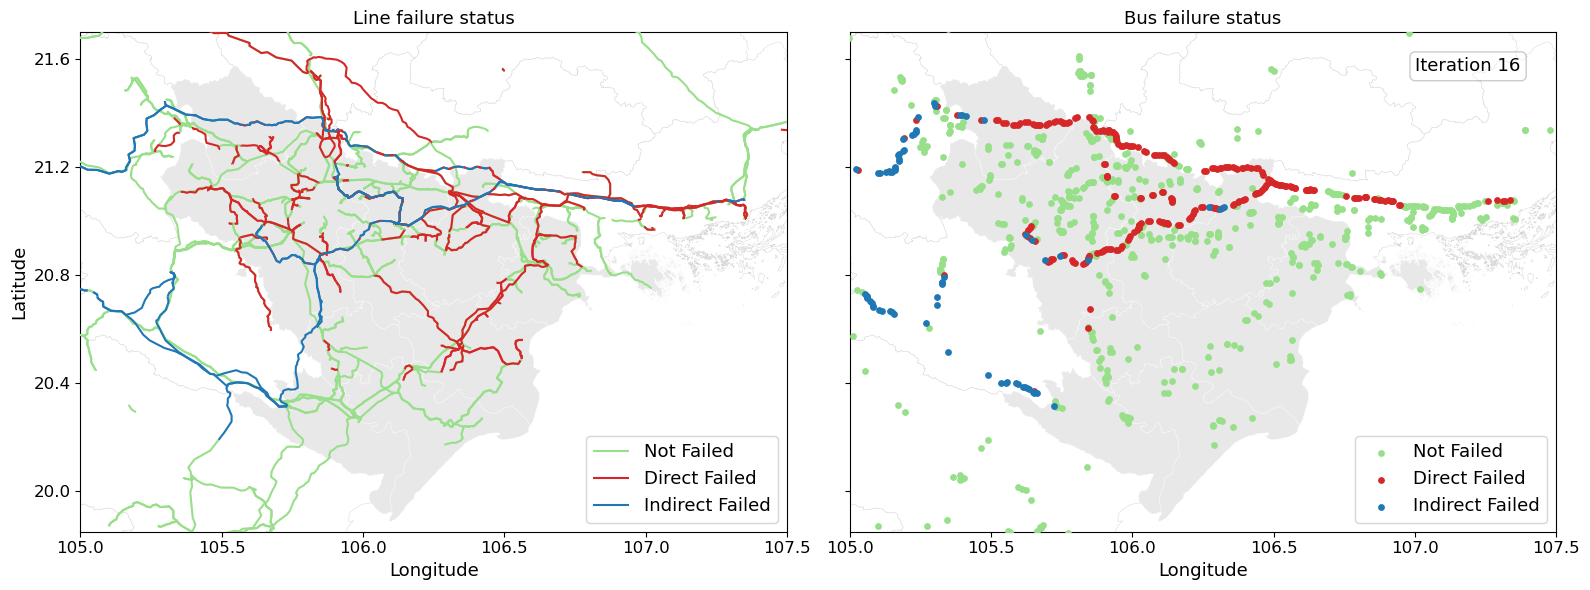

In [10]:
# plot_failure_impact_maps(lines_gdf_sim_update, nodes_gdf_sim_update, basemap, fig_path=output_dir)

In [11]:
lines_gdf_update = compute_failure_probabilities(lines_gdf_sim_update)
nodes_gdf_update = compute_failure_probabilities(nodes_gdf_sim_update)

In [12]:
# lines_gdf = lines_gdf.drop(columns=["overload_count", "overload_prob","overload_count"], errors="ignore")

In [13]:
# Merge overload ratio stats
# === Step 1: 统计每条线路超载次数 ===
overload_count = overload_lines_df.groupby("line_name").size().rename("overload_count").reset_index()
# 真实参与仿真的总次数（成功且线路有结果）
sim_combinations = overload_lines_df["fail_iter"].drop_duplicates()
num_simulations = sim_combinations.shape[0]

overload_count["overload_prob"] = overload_count["overload_count"] / num_simulations
overload_count = overload_count.sort_values("overload_prob", ascending=False)
overload_count.to_csv(os.path.join(base_dir, "overloaded_line_stats.csv"))

lines_gdf = lines_gdf.merge(overload_count.rename(columns={"line_name": "LineID"}), on="LineID", how="left")
lines_gdf["overload_prob"] = lines_gdf["overload_prob"].fillna(0)

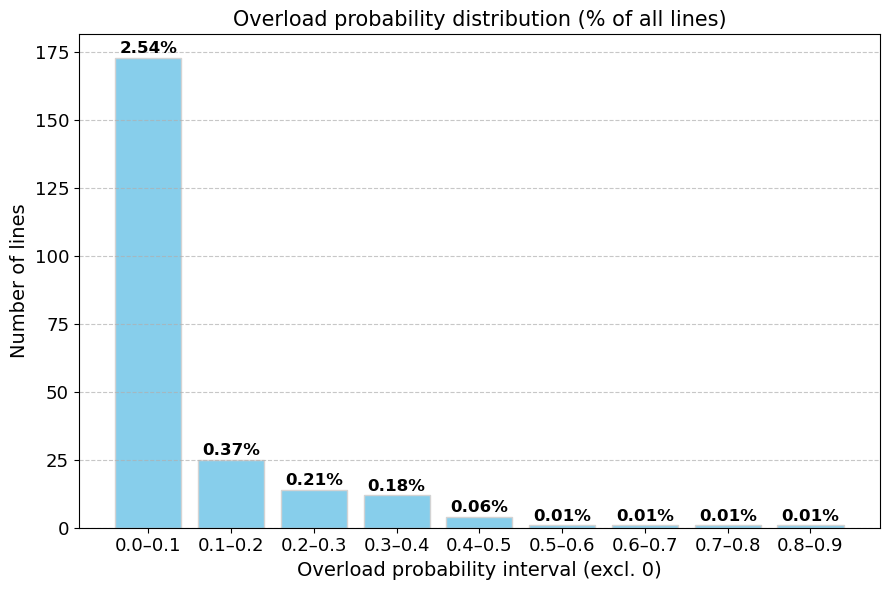

In [15]:
plot_overload_histogram(lines_gdf, output_dir, basemap)

In [ ]:
# def normalize_line_records(df):
#     """
#     Normalize failed / overloaded line records to:
#     columns = ['iter', 'line']
#     """

#     out = df.copy()

#     # 1. iteration: fail_iter -> integer
#     # e.g. 'fail_iter_123' -> 123
#     out["iter"] = (
#         out["fail_iter"]
#         .astype(str)
#         .str.extract(r"(\d+)")
#         .astype(int)
#     )

#     # 2. line identifier
#     out["line"] = out["line_name"].astype(str)

#     # 3. keep minimal columns & deduplicate
#     out = out[["iter", "line"]].drop_duplicates().reset_index(drop=True)

#     return out


# def cooccurrence_diagnostics_from_df(
#     failed_lines_df,
#     overload_lines_df,
#     top_lines=None,
#     top_n=10,
#     k_associated=10,
#     output_dir=None,
# ):
#     """
#     Diagnose co-occurrence between overloaded lines and failed lines.
#     Tailored to records with columns: fail_iter, line_name.
#     """

#     # --- normalize ---
#     failed = normalize_line_records(failed_lines_df)
#     overload = normalize_line_records(overload_lines_df)

#     # --- universe of iterations ---
#     iters = sorted(set(failed["iter"]).union(set(overload["iter"])))
#     n_iters = len(iters)

#     print(f"[INFO] Total iterations detected: {n_iters}")

#     # --- build iteration sets ---
#     failed_iters_by_line = failed.groupby("line")["iter"].apply(set).to_dict()
#     overload_iters_by_line = overload.groupby("line")["iter"].apply(set).to_dict()

#     # --- determine top overloaded lines ---
#     if top_lines is None:
#         freq = pd.Series(
#             {l: len(s) / n_iters for l, s in overload_iters_by_line.items()},
#             name="p_overload"
#         )
#         top_lines = (
#             freq.sort_values(ascending=False)
#                 .head(top_n)
#                 .index
#                 .tolist()
#         )

#     # --- overview table ---
#     top_overview = []
#     for L in top_lines:
#         oset = overload_iters_by_line.get(L, set())
#         top_overview.append({
#             "top_overloaded_line": L,
#             "n_overload_iters": len(oset),
#             "p_overload": len(oset) / n_iters
#         })

#     top_overview = (
#         pd.DataFrame(top_overview)
#         .sort_values("p_overload", ascending=False)
#         .reset_index(drop=True)
#     )

#     # --- co-occurrence diagnostics ---
#     rows = []

#     for L in top_lines:
#         oset = overload_iters_by_line.get(L, set())
#         n_over = len(oset)

#         if n_over == 0:
#             continue

#         for F, fset in failed_iters_by_line.items():
#             n_fail = len(fset)
#             if n_fail == 0:
#                 continue

#             A = len(oset & fset)   # overload AND failed
#             if A == 0:
#                 continue

#             B = n_over - A
#             C = n_fail - A
#             D = n_iters - (A + B + C)

#             p_over_given_fail = A / n_fail
#             p_over_given_notfail = (
#                 B / (n_iters - n_fail) if (n_iters - n_fail) > 0 else np.nan
#             )

#             risk_ratio = (
#                 p_over_given_fail / p_over_given_notfail
#                 if p_over_given_notfail not in [0, np.nan] else np.inf
#             )

#             p_over = n_over / n_iters
#             p_fail = n_fail / n_iters
#             lift = (A / n_iters) / (p_over * p_fail)

#             denom = np.sqrt((A+B)*(C+D)*(A+C)*(B+D))
#             phi = (A*D - B*C) / denom if denom > 0 else np.nan

#             rows.append({
#                 "top_overloaded_line": L,
#                 "failed_line": F,
#                 "A_over_and_fail": A,
#                 "p_overload_given_failed": p_over_given_fail,
#                 "p_overload_given_not_failed": p_over_given_notfail,
#                 "risk_ratio": risk_ratio,
#                 "lift": lift,
#                 "phi": phi
#             })

#     summary = pd.DataFrame(rows)

#     summary_top = (
#         summary.sort_values(
#             ["top_overloaded_line", "lift", "phi", "risk_ratio"],
#             ascending=[True, False, False, False]
#         )
#         .groupby("top_overloaded_line", as_index=False)
#         .head(k_associated)
#         .reset_index(drop=True)
#     )

#     # --- save ---
#     if output_dir is not None:
#         os.makedirs(output_dir, exist_ok=True)
#         top_overview.to_csv(
#             os.path.join(output_dir, "top_overloaded_lines_overview.csv"),
#             index=False
#         )
#         summary_top.to_csv(
#             os.path.join(output_dir, "top_overloaded_lines_associated_failed_lines.csv"),
#             index=False
#         )

#     return summary_top, top_overview


In [ ]:
# summary_top, top_overview = cooccurrence_diagnostics_from_df(
#     failed_lines_df=failed_lines_df,
#     overload_lines_df=overload_lines_df,
#     top_lines=None,
#     top_n=10,
#     k_associated=10,
#     output_dir=output_dir
# )

# summary_top.head()

[INFO] Total iterations detected: 1000


,top_overloaded_line,failed_line,A_over_and_fail,p_overload_given_failed,p_overload_given_not_failed,risk_ratio,lift,phi
0,LINEVN0001a,LINEVN0460a,7,0.875000,0.606855,1.441860,1.436782,0.048952
1,LINEVN0001a,LINEVN0460b,7,0.875000,0.606855,1.441860,1.436782,0.048952
2,LINEVN0001a,LINEVN0201,8,0.800000,0.607071,1.317804,1.313629,0.039339
3,LINEVN0001a,LINEVN0202,8,0.800000,0.607071,1.317804,1.313629,0.039339
4,LINEVN0001a,LINEVN1617,22,0.758621,0.604531,1.254890,1.245683,0.052989


In [ ]:
# def get_top10_overload_lines(
#     lines_with_ratio,
#     output_dir=None,
#     prob_col="overload_prob",
#     crs_out="EPSG:4326",
#     save_gpkg=True,
#     save_csv=True,
# ):
#     """
#     Extract top 10 transmission lines with highest failure / overload probability.

#     Parameters
#     ----------
#     lines_with_ratio : GeoDataFrame
#         Transmission lines with failure probability attribute.
#     output_dir : str or None
#         Directory to save outputs. If None, only return GeoDataFrame.
#     prob_col : str
#         Column name for failure probability.
#     crs_out : str
#         Output CRS.
#     save_gpkg : bool
#         Save as GeoPackage.
#     save_csv : bool
#         Save as CSV (geometry dropped).

#     Returns
#     -------
#     gdf_top10 : GeoDataFrame
#         Top 10 lines by failure probability.
#     """

#     gdf = lines_with_ratio.copy()
#     gdf = gdf.to_crs(crs_out)

#     # Safety: fill NA with 0
#     gdf[prob_col] = gdf[prob_col].fillna(0)

#     # Sort and select top 10
#     gdf_top10 = (
#         gdf.sort_values(prob_col, ascending=False)
#            .head(10)
#            .reset_index(drop=True)
#     )

#     # Add ranking
#     gdf_top10["rank"] = range(1, len(gdf_top10) + 1)

#     if output_dir is not None:
#         os.makedirs(output_dir, exist_ok=True)

#         if save_gpkg:
#             gpkg_path = os.path.join(output_dir, "top10_failure_lines.gpkg")
#             gdf_top10.to_file(gpkg_path, layer="top10_lines", driver="GPKG")

#         if save_csv:
#             csv_path = os.path.join(output_dir, "top10_failure_lines.csv")
#             gdf_top10.drop(columns="geometry").to_csv(csv_path, index=False)

#     return gdf_top10


# def plot_top10_overload_lines(
#     gdf_top10,
#     basemap=None,
#     output_dir=None,
#     fname="top10_failure_lines_map.png",
# ):
#     """
#     Plot top 10 failure probability lines on a map.
#     """

#     fig, ax = plt.subplots(1, 1, figsize=(8, 10))

#     if basemap is not None:
#         basemap = basemap.to_crs(gdf_top10.crs)
#         basemap.plot(ax=ax, color="lightgrey", linewidth=0.3)

#     gdf_top10.plot(
#         ax=ax,
#         column="overload_prob",
#         cmap="Reds",
#         linewidth=2.5,
#         legend=True,
#         legend_kwds={"label": "Failure probability"}
#     )

#     # Label rank
#     for _, row in gdf_top10.iterrows():
#         ax.annotate(
#             text=str(row["rank"]),
#             xy=(row.geometry.centroid.x, row.geometry.centroid.y),
#             fontsize=10,
#             fontweight="bold",
#             ha="center",
#             va="center",
#             color="black"
#         )

#     ax.set_title("Top 10 transmission lines by failure probability", fontsize=13)
#     ax.set_axis_off()

#     if output_dir is not None:
#         os.makedirs(output_dir, exist_ok=True)
#         plt.savefig(os.path.join(output_dir, fname), dpi=600, bbox_inches="tight")

#     plt.tight_layout()
#     plt.show()

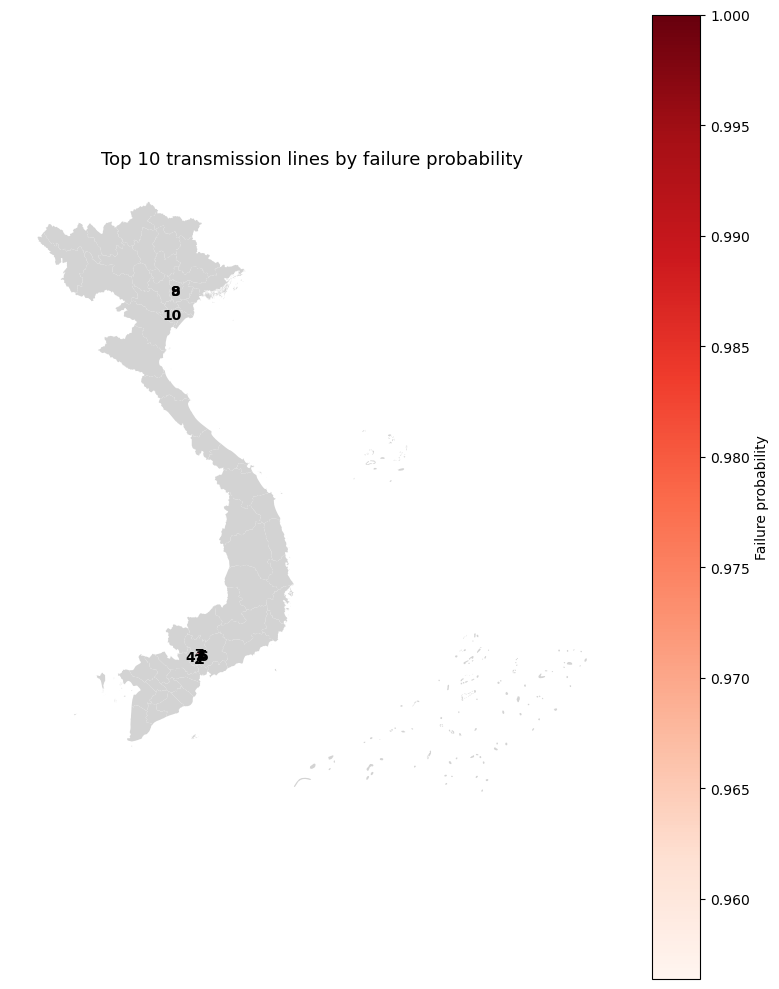

In [ ]:
# top10_lines = get_top10_overload_lines(
#     lines_with_ratio=lines_gdf,
#     output_dir=output_dir,
#     prob_col="overload_prob"
# )

# plot_top10_overload_lines(
#     gdf_top10=top10_lines,
#     basemap=basemap,
#     output_dir=output_dir
# )

In [35]:
def plot_combined_failure_maps_extended(lines_gdf, nodes_gdf, basemap, fig_path=None):
    # Ensure proper CRS
    lines_gdf = lines_gdf.to_crs("EPSG:4326")
    nodes_gdf = nodes_gdf.to_crs("EPSG:4326")
    basemap = basemap.to_crs("EPSG:4326")

    # Filter region
    pcode_list = ['VN106', 'VN111', 'VN101', 'VN107', 'VN103', 'VN109', 'VN113', 'VN117', 'VN115', 'VN104']
    target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
    other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

    # Clip all layers to the map extent to remove out-of-view geometry from SVG
    from shapely.geometry import box as _sbox
    _clip_box = _sbox(105, 19.85, 107.5, 21.7)
    target_regions = target_regions.clip(_clip_box)
    other_regions = other_regions.clip(_clip_box)
    lines_gdf = lines_gdf.clip(_clip_box)
    nodes_gdf = nodes_gdf.clip(_clip_box)

    # Compute majority failure status and probability
    def compute_majority_with_prob(gdf):
        impact_cols = [col for col in gdf.columns if col.startswith("impact_")]
        mode_vals = gdf[impact_cols].mode(axis=1)[0]
        probs = []
        for idx, row in gdf.iterrows():
            status_counts = row[impact_cols].value_counts(normalize=True)
            mode = mode_vals.loc[idx]
            probs.append(status_counts.get(mode, 0.0))
        gdf['majority_status'] = mode_vals
        gdf['majority_prob'] = probs
        return gdf

    lines_gdf = compute_majority_with_prob(lines_gdf)
    nodes_gdf = compute_majority_with_prob(nodes_gdf)

    # Color definitions
    status_colors = {
        'Not Failed': '#98DF8A',
        'Direct Failed': '#D62728',
        'Indirect Failed': '#1F77B4'
    }

    cmap = cm.Reds
    norm = colors.Normalize(vmin=0, vmax=1)

    fig, axes = plt.subplots(3, 2, figsize=(16, 18), gridspec_kw={'hspace': 0.05, 'wspace': 0.01})
    row_labels = ["Majority failure status", "Direct failure probability", "Indirect failure probability"]
    col_labels = ["Line", "Bus"]

    col_pairs = [
        (lines_gdf, 'majority_status', 'majority_prob'),
        (nodes_gdf, 'majority_status', 'majority_prob'),
        (lines_gdf, 'p_direct', None),
        (nodes_gdf, 'p_direct', None),
        (lines_gdf, 'p_indirect', None),
        (nodes_gdf, 'p_indirect', None),
    ]

    for i, (ax, (gdf, status_col, prob_col)) in enumerate(zip(axes.flat, col_pairs)):
        row, col = divmod(i, 2)
        target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5, alpha=0.5, zorder=0, rasterized=True)
        other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.3, zorder=0, rasterized=True)

        if prob_col is not None:
            # Plot each status
            for status, color in status_colors.items():
                subset = gdf[gdf['majority_status'] == status]
                if subset.empty:
                    continue
                if subset.geometry.iloc[0].geom_type == 'Point':
                    subset.plot(ax=ax, color=color, markersize=15, label=status, zorder=3)
                else:
                    subset.plot(ax=ax, color=color, linewidth=1.5, label=status, zorder=3)
                
        else:
            if gdf.geometry.iloc[0].geom_type == 'Point':
                gdf[gdf[status_col] == 0].plot(ax=ax, color='#98DF8A', markersize=10, alpha=0.5, zorder=2, rasterized=True)
                gdf[gdf[status_col] > 0].plot(ax=ax, column=status_col, cmap=cmap, norm=norm,
                                              markersize=30, alpha=0.9, zorder=3, rasterized=True)
            else:
                gdf[gdf[status_col] == 0].plot(ax=ax, color='#98DF8A', linewidth=0.5, alpha=0.5, zorder=2, rasterized=True)
                gdf[gdf[status_col] > 0].plot(ax=ax, column=status_col, cmap=cmap, norm=norm,
                                              linewidth=1.2, zorder=3, rasterized=True)

        ax.set_xlim(105, 107.5)
        ax.set_ylim(19.85, 21.7)

        ax.tick_params(axis='both', which='major', labelsize=13)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        
        if row == 2:
            ax.set_xlabel("Longitude", fontsize=15)
        else:
            ax.set_xticklabels([])
        if col == 0:
            ax.set_ylabel("Latitude", fontsize=15)
        else:
            ax.tick_params(labelleft=False)

        if prob_col is not None:
            ax.legend(loc='lower right', fontsize=15)

    # Add super labels
    for ax, col_label in zip(axes[0], col_labels):
        ax.annotate(col_label, xy=(0.5, 1.03), xycoords='axes fraction',
                    ha='center', va='center', fontsize=15, fontweight='bold')

    for ax, row_label in zip(axes[:, 0], row_labels):
        ax.annotate(row_label, xy=(-0.17, 0.5), xycoords='axes fraction',
                    ha='center', va='center', fontsize=15, fontweight='bold', rotation=90)

    # Add single colorbar aligned to rows 1 and 2
    pos1 = axes[1, 1].get_position()
    pos2 = axes[2, 1].get_position()
    cbar_ax = fig.add_axes([pos2.x1 + 0.01, pos2.y0, 0.015, pos1.y1 - pos2.y0])

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Failure probability", fontsize=15)
    cbar.ax.tick_params(labelsize=13)

    # Save or show
    if fig_path:
        os.makedirs(fig_path, exist_ok=True)
        plt.savefig(os.path.join(fig_path, "combined_failure_maps_extended.png"), dpi=800, bbox_inches="tight")
        plt.savefig(os.path.join(fig_path, "combined_failure_maps_extended.svg"), dpi=600, bbox_inches="tight")


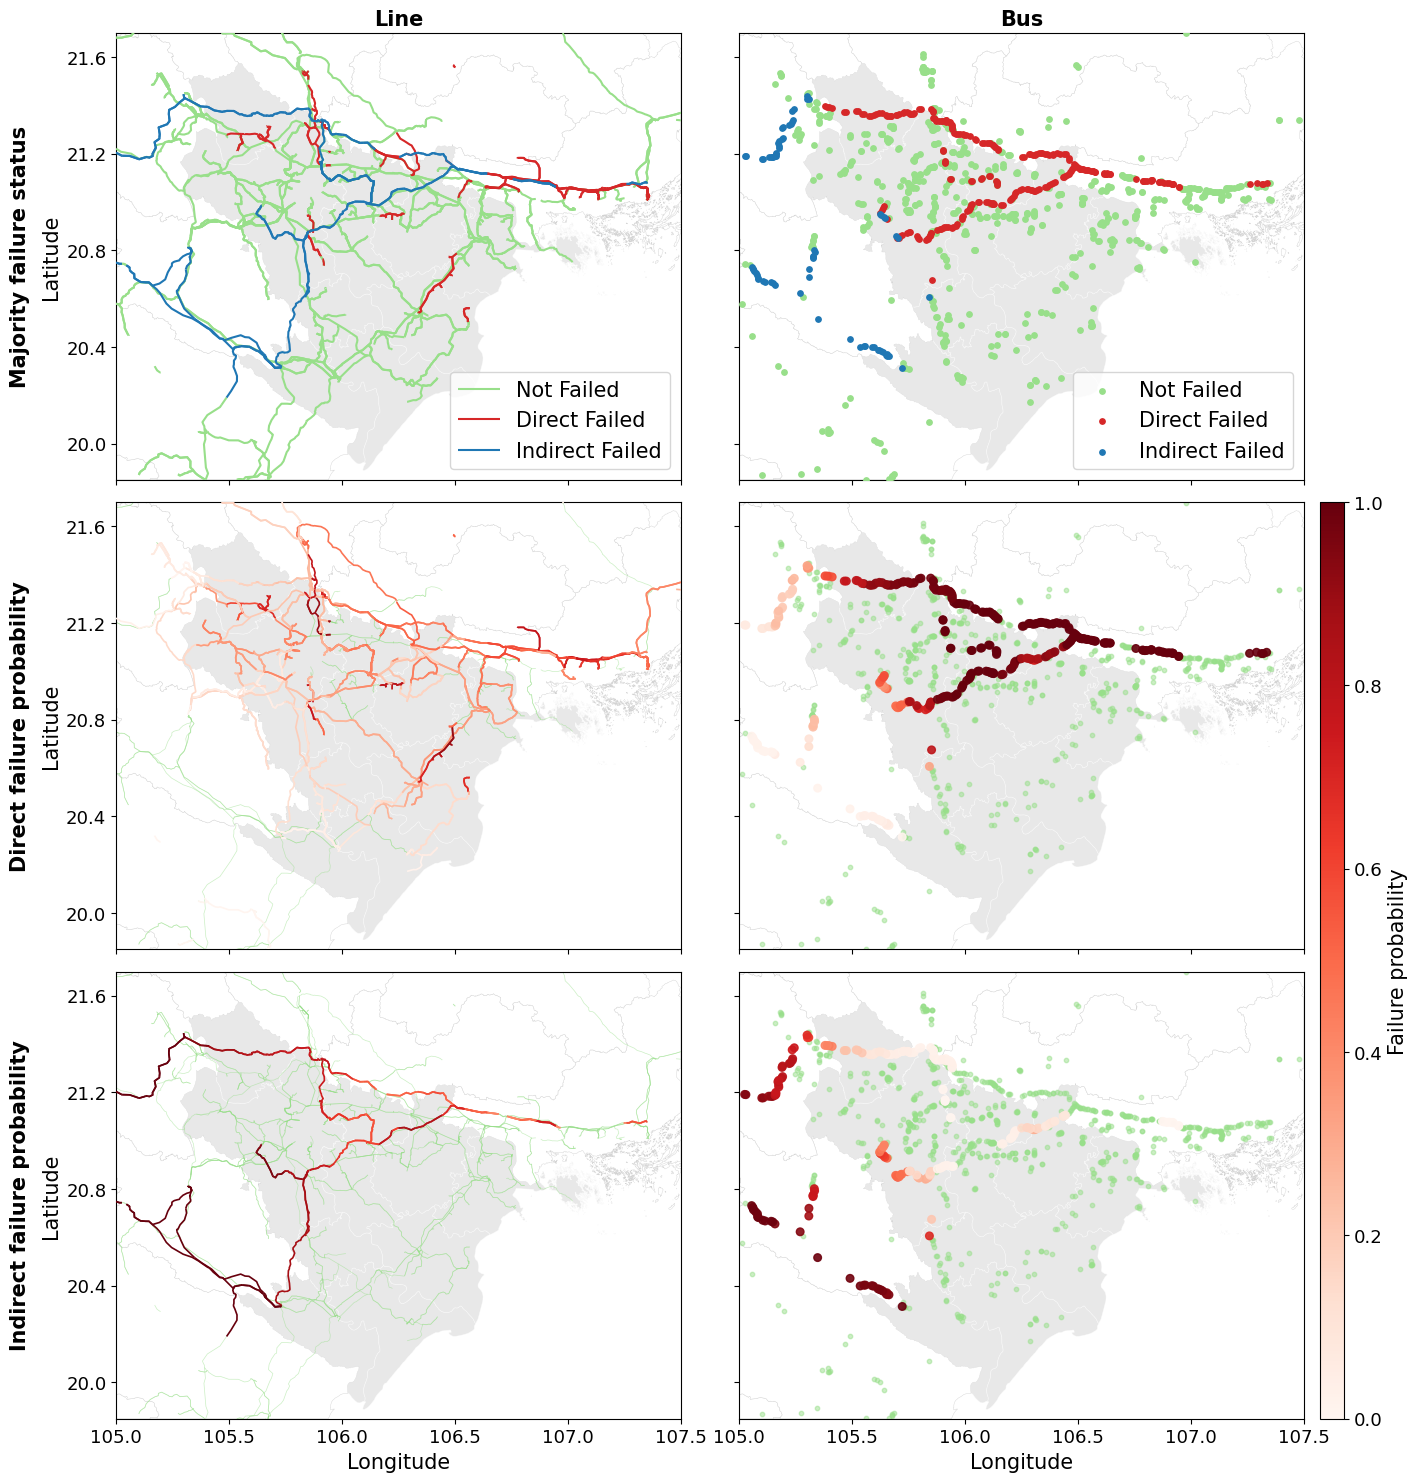

In [36]:
plot_combined_failure_maps_extended(lines_gdf_update, nodes_gdf_update, basemap, fig_path=output_dir)

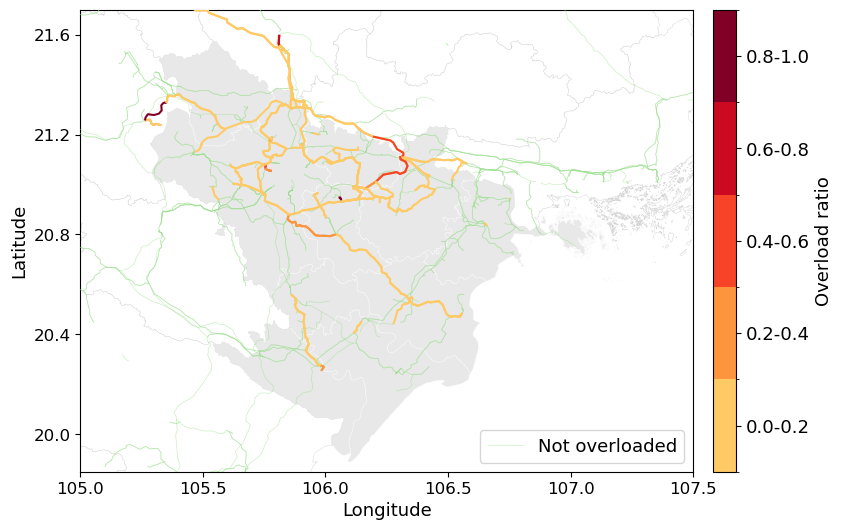

In [23]:
plot_overload_by_adm_ref_fixed_bins(lines_gdf, output_path=output_dir, basemap=basemap)

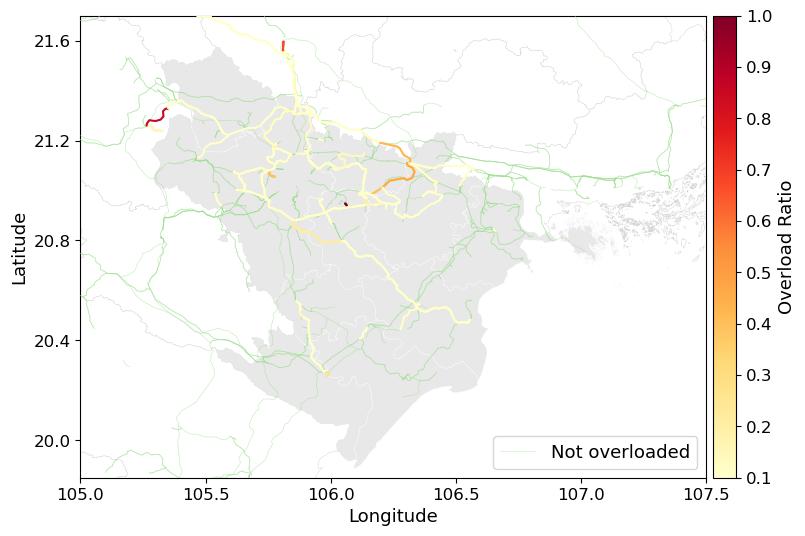

In [21]:
overload_lines = plot_overload_by_adm_ref_continous(lines_gdf, output_path=output_dir, basemap=basemap)

In [24]:
# # === Quantitative analysis of overloaded lines ===
# total_lines = len(lines_gdf)
# overloaded_count = len(overload_lines)
# overloaded_ratio = overloaded_count / total_lines * 100

# print(f"Total lines: {total_lines}")
# print(f"Overloaded lines: {overloaded_count} ({overloaded_ratio:.2f}%)")
# print(f"Overload probability - mean: {overload_lines['overload_prob'].mean():.3f}, "
#         f"median: {overload_lines['overload_prob'].median():.3f}, "
#         f"max: {overload_lines['overload_prob'].max():.3f}")

# # Top 10 overloaded lines
# print("\nTop 10 lines by overload probability:")
# print(overload_lines[['LineID', 'overload_prob']].sort_values(
#     'overload_prob', ascending=False).head(20))

# # Stats by province if ADM1_PCODE exists
# if 'ADM1_PCODE' in overload_lines.columns:
#     province_stats = (
#         overload_lines.groupby('ADM1_PCODE')['overload_prob']
#         .agg(['count', 'mean', 'max'])
#         .sort_values('mean', ascending=False)
#     )
#     print("\nOverload stats by province:")
#     print(province_stats)


TypeError: object of type 'NoneType' has no len()

ValueError: too many values to unpack (expected 2)

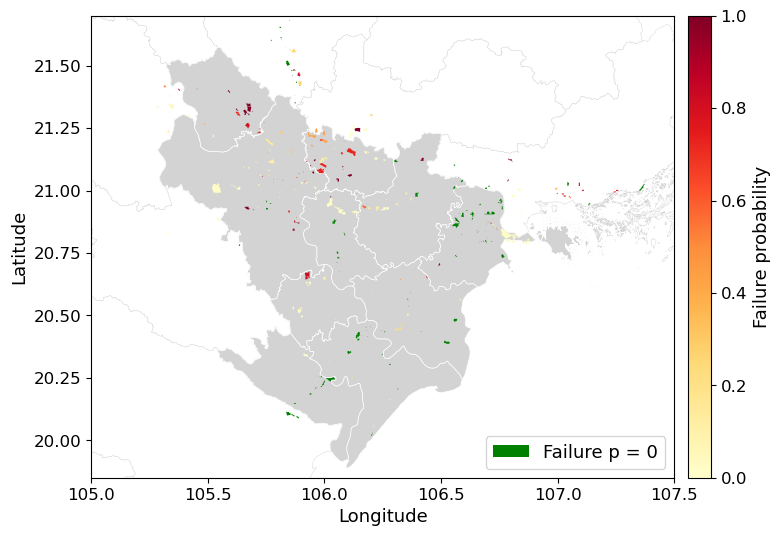

In [26]:
loads_gdf_update, failed_loads = plot_load_failure_probability(load_status_df, loads_gdf, results_df, basemap=basemap, output_path=output_dir)

In [ ]:
# === Quantitative analysis of failed loads ===
total_loads = len(loads_gdf)
failed_count = len(failed_loads)
failed_ratio = failed_count / total_loads * 100

print(f"Total loads: {total_loads}")
print(f"Failed loads: {failed_count} ({failed_ratio:.2f}%)")
print(f"Failure probability - mean: {failed_loads['failure_probability'].mean():.3f}, "
      f"median: {failed_loads['failure_probability'].median():.3f}, "
      f"max: {failed_loads['failure_probability'].max():.3f}")

# Top 10 failed loads
print("\nTop 10 loads by failure probability:")
print(failed_loads[['osmid', 'failure_probability', 'served_ratio']].sort_values(
    'failure_probability', ascending=False).head(100))

# If province info exists in loads_gdf
if 'province' in loads_gdf.columns:
    province_stats = (
        failed_loads.groupby('province')['failure_probability']
        .agg(['count', 'mean', 'max'])
        .sort_values('mean', ascending=False)
    )
    print("\nFailure stats by province:")
    print(province_stats)


Total loads: 1378
Failed loads: 358 (25.98%)
Failure probability - mean: 0.318, median: 0.101, max: 1.000

Top 10 loads by failure probability:
           osmid  failure_probability  served_ratio
1279   875944784             1.000000      0.000000
1274  1119170923             1.000000      0.000000
920    210752755             1.000000      0.000000
1251   708617214             1.000000      0.000000
1252   708617216             1.000000      0.000000
1291   704069818             1.000000      0.000000
1346   596051637             1.000000      0.000000
1257   875944834             1.000000      0.000000
1021   593793800             1.000000      0.000000
1275  1119170920             1.000000      0.000000
1193   659860835             1.000000      0.000000
1302   875641765             1.000000      0.000000
1332   596051687             1.000000      0.000000
1333   595824021             1.000000      0.000000
1301   549956792             1.000000      0.000000
1282   642268658        

In [31]:
df_all, df_median, df_std, df_avg, failure_ratio, avg_failed_ratio = analyze_load_served_ratio_by_adm(
    loads_gdf=loads_gdf,
    load_status_df=load_status_df,
    results_df=results_df,
    net_dir=base_dir,
    output_path=base_dir
)

✓ Found 619 successful iterations


KeyboardInterrupt: 

In [43]:
def plot_served_ratio_maps(loads_gdf, fig_path=None, basemap=None):
    # Average served ratio of all fail_iters
    loads_gdf = loads_gdf.to_crs("EPSG:4326")
    basemap = basemap.to_crs("EPSG:4326")

    pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104']
    target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
    other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

    # Clip all layers to plotting extent so out-of-view geometries are not saved
    from shapely.geometry import box as _sbox
    _clip_box = _sbox(105, 19.85, 107.5, 21.7)
    target_regions = target_regions.clip(_clip_box)
    other_regions = other_regions.clip(_clip_box)
    loads_gdf = loads_gdf.clip(_clip_box)

    # unique_iters = loads_gdf["fail_iter"].dropna().unique()
    # 聚合：按 geometry 平均 served_ratio_mean（也可替换为 load_id）
    avg_served = loads_gdf.groupby(loads_gdf.geometry).agg({
        'served_ratio_mean': 'mean'
    }).reset_index()
    avg_served_gdf = gpd.GeoDataFrame(avg_served, geometry='geometry', crs=loads_gdf.crs)

    vmin = avg_served_gdf["served_ratio_mean"].min()
    vmax = avg_served_gdf["served_ratio_mean"].max()
    # vmin = loads_gdf["served_ratio_mean"].min()
    # vmax = loads_gdf["served_ratio_mean"].max()    
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.colormaps.get_cmap("RdYlGn")

    # for iter_label in unique_iters:
    #     iter_data = loads_gdf[loads_gdf["fail_iter"] == iter_label]

    fig, ax = plt.subplots(figsize=(8, 7))

    ax.set_xlabel("Longitude", fontsize=14)
    ax.set_ylabel("Latitude", fontsize=14)
    ax.set_xlim(105, 107.5)
    ax.set_ylim(19.85, 21.7)
    ax.set_aspect('auto')
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.8, zorder=1, rasterized=True)
    other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.5, zorder=0, rasterized=True)
    # iter_data.plot(ax=ax, column="served_ratio_mean", cmap=cmap, norm=norm, markersize=100, legend=False, zorder=2)
    avg_served_gdf.plot(ax=ax, column="served_ratio_mean", cmap=cmap, norm=norm,
                        markersize=100, legend=False, zorder=2, rasterized=True)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.035)
    cbar.set_label("Served load ratio", fontsize=14)
    cbar.ax.tick_params(labelsize=13)

    if fig_path:
        os.makedirs(fig_path, exist_ok=True)
        plt.savefig(os.path.join(fig_path, 'served_ratio_map_average.png'), dpi=800, bbox_inches="tight")
        plt.savefig(os.path.join(fig_path, 'served_ratio_map_average.svg'), dpi=600, bbox_inches="tight")

In [40]:
loads_gdf_update = prepare_loads_map(load_status_df, loads_gdf)

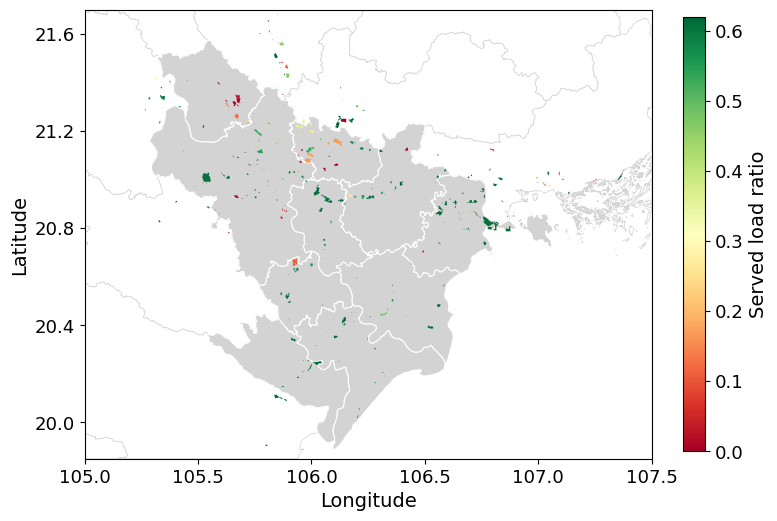

In [44]:
plot_served_ratio_maps(loads_gdf_update, fig_path=output_dir, basemap=basemap)